# Ex 1

In [203]:
import torch
torch.backends.cudnn.deterministic = True
v = torch.tensor([
    [1, 2, -3, 4, 0],
    [5, 6, 7, 8, 2],
    [5, 10, 1, 12, 11],
    [0, 0, 1, 2, -4]
])

# Sum of each column (dim=0)
col_sums = torch.sum(v, dim=0)
# Sum of each row (dim=1)
row_sums = torch.sum(v, dim=1)

print("Column sums:", col_sums)
print("Row sums:", row_sums)

Column sums: tensor([11, 18,  6, 26,  9])
Row sums: tensor([ 4, 28, 39, -1])


# Ex 2

In [204]:
import torchvision
from torchvision import transforms
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch import nn

In [205]:
def load_data_CIFAR100(batch_size, resize=None):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    CIFAR100_train = torchvision.datasets.CIFAR10(
        root="../data", train=True, transform=trans, download=True
    )
    CIFAR100_test = torchvision.datasets.CIFAR10(
        root="../data", train=False, transform=trans, download=True
    )
    CIFAR100_train, CIFAR100_val = torch.utils.data.random_split(
        CIFAR100_train, [4000, 46000], generator=torch.Generator().manual_seed(42)
    )
    return (
        torch.utils.data.DataLoader(
            CIFAR100_train, batch_size, shuffle=True, num_workers=2
        ),
        torch.utils.data.DataLoader(
            CIFAR100_val, batch_size, shuffle=False, num_workers=2
        ),
        torch.utils.data.DataLoader(
            CIFAR100_test, batch_size, shuffle=False, num_workers=2
        ),
    )

In [206]:
batch_size = 512

train_iter, val_iter, test_iter = load_data_CIFAR100(batch_size)

In [207]:
num_epochs = 10
lr = 0.2

In [208]:
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3072, 512),  # 3 * 32 * 32 input, 512 hidden units output
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 100),  # 512 in, 10 classes out
)

In [209]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)


net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=512, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=512, out_features=100, bias=True)
)

In [210]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

In [211]:
def evaluate_accuracy(net, data_iter):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples * 100

In [212]:
def train_epoch(net, train_iter, loss, optimizer):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples * 100

In [213]:
def train(net, train_iter, val_iter, loss, num_epochs, optimizer):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(
            f"Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}"
        )

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [214]:
test_loss, test_acc = evaluate_accuracy(net, test_iter)
print(f"Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}")

Test loss 4.59, Test accuracy 2.20


# Ex 3

In [215]:
import torchvision
from torchvision import transforms
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch import nn

In [264]:
class ConvolutionalBlock(nn.Module):
    def __init__(self, in_channels):
        super(ConvolutionalBlock, self).__init__()

        # Branch 1
        self.conv1x1_1 = nn.Conv2d(in_channels, 32, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()

        # Branch 2
        self.conv1x1_2 = nn.Conv2d(in_channels, 32, kernel_size=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()

        self.conv3x3_3 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.relu3 = nn.ReLU()

        # Fusion
        self.conv1x1_4 = nn.Conv2d(64, 3, kernel_size=1)

        # Finish
        self.avgpool = nn.AvgPool2d(kernel_size=2, stride=16)

    def forward(self, x):
        # Branch 1
        branch1 = self.conv1x1_1(x)
        branch1 = self.bn1(branch1)
        branch1 = self.relu1(branch1)

        # Branch 2
        branch2 = self.conv1x1_2(x)
        branch2 = self.bn2(branch2)
        branch2 = self.relu2(branch2)
        branch2 = self.conv3x3_3(branch2)
        branch2 = self.bn3(branch2)
        branch2 = self.relu3(branch2)

        # Fusion
        out = torch.cat([branch1, branch2], dim=1)
        out = self.conv1x1_4(out)

        # Add
        out = torch.add(x, out)

        return self.avgpool(out)

In [263]:
# modelul complet

net = nn.Sequential(
    ConvolutionalBlock(3),
    nn.Flatten(),
    nn.Linear(12, 100),
)

net

Sequential(
  (0): ConvolutionalBlock(
    (conv1x1_1): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU()
    (conv1x1_2): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU()
    (conv3x3_3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu3): ReLU()
    (conv1x1_4): Conv2d(64, 3, kernel_size=(1, 1), stride=(1, 1))
    (avgpool): AvgPool2d(kernel_size=2, stride=16, padding=0)
  )
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=12, out_features=100, bias=True)
)

In [265]:
X = torch.randn(1, 3, 32, 32)

for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, " output shape : \t", X.shape)

ConvolutionalBlock  output shape : 	 torch.Size([1, 3, 2, 2])
Flatten  output shape : 	 torch.Size([1, 12])
Linear  output shape : 	 torch.Size([1, 100])


In [266]:
def load_data_CIFAR100(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    CIFAR100_train = torchvision.datasets.CIFAR100(
        root="../data", train=True, transform=trans, download=True
    )
    CIFAR100_test = torchvision.datasets.CIFAR100(
        root="../data", train=False, transform=trans, download=True
    )
    CIFAR100_train, CIFAR100_val = torch.utils.data.random_split(
        CIFAR100_train, [9000, 41000], generator=torch.Generator().manual_seed(42)
    )
    return (
        torch.utils.data.DataLoader(
            CIFAR100_train, batch_size, shuffle=True, num_workers=2
        ),
        torch.utils.data.DataLoader(
            CIFAR100_val, batch_size, shuffle=False, num_workers=2
        ),
        torch.utils.data.DataLoader(
            CIFAR100_test, batch_size, shuffle=False, num_workers=2
        ),
    )

In [267]:
def evaluate_accuracy(net, data_iter, loss, device):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples * 100

In [268]:
def train_epoch(net, train_iter, loss, optimizer, device):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples * 100

In [269]:
def train(net, train_iter, val_iter, test_iter, num_epochs, lr, device):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []

    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)

    net.apply(init_weights)
    print("Training on", device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer, device)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter, loss, device)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(
            f"Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}"
        )
    test_loss, test_acc = evaluate_accuracy(net, test_iter, loss, device)
    print(f"Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}")

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [270]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f"cuda:{i}")
    return torch.device("cpu")

In [271]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, "bo", label="Training loss")
    plt.plot(epochs, val_loss_all, "b", label="Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [272]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, "bo", label="Training acc")
    plt.plot(epochs, val_acc_all, "b", label="Validation acc")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

In [273]:
batch_size, lr, num_epochs = 256, 0.05, 5
train_iter, val_iter, test_iter = load_data_CIFAR100(batch_size)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(
    net, train_iter, val_iter, test_iter, num_epochs, lr, try_gpu()
)  # 2 min

Training on cuda:0
Epoch 1, Train loss 4.64, Train accuracy 1.21, Validation loss 4.63, Validation accuracy 1.29
Epoch 2, Train loss 4.59, Train accuracy 1.67, Validation loss 4.60, Validation accuracy 1.71
Epoch 3, Train loss 4.58, Train accuracy 2.02, Validation loss 4.58, Validation accuracy 2.06
Epoch 4, Train loss 4.56, Train accuracy 2.09, Validation loss 4.56, Validation accuracy 2.22
Epoch 5, Train loss 4.54, Train accuracy 2.62, Validation loss 4.55, Validation accuracy 2.56
Test loss 4.55, Test accuracy 2.39


In [274]:
device = try_gpu()
test_loss, test_acc = evaluate_accuracy(net, test_iter, nn.CrossEntropyLoss(), device)
print(f'Test loss: {test_loss:.2f}, Test accuracy: {test_acc:.2f}')

Test loss: 4.55, Test accuracy: 2.39


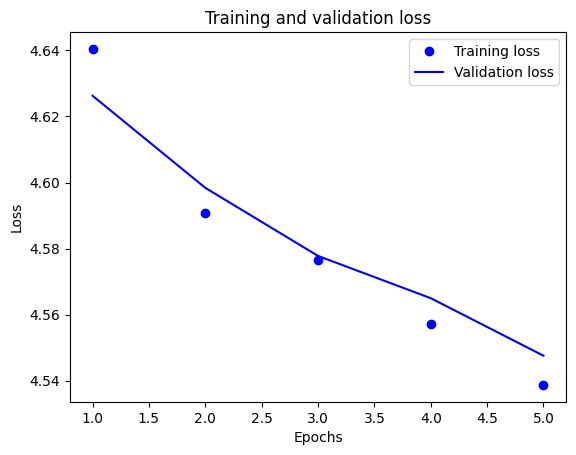

In [275]:
plot_loss(train_loss_all, val_loss_all)

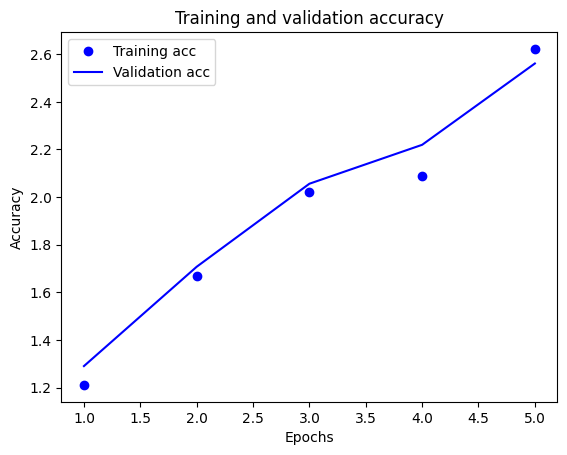

In [276]:
plot_accuracy(train_acc_all, val_acc_all)

# Ex 4

In [230]:
import hashlib
import os
import requests
import re
import collections
import random
import torch
from torch import nn
from torch.nn import functional as F
import math
import matplotlib.pyplot as plt
import zipfile

torch.manual_seed(42)

In [231]:
def download(url, cache_dir=os.path.join("..", "data")):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split("/")[-1])
    if os.path.exists(fname):
        with open(fname, "rb") as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f"Downloading {fname} from {url}...")
    r = requests.get(url, stream=True, verify=True)
    with open(fname, "wb") as f:
        f.write(r.content)
    return fname

In [232]:
def read_book():
    """Load the time machine dataset into a list of text lines."""
    with open(
        download("http://s3.amazonaws.com/text-datasets/nietzsche.txt"), "r"
    ) as f:
        lines = f.readlines()
    return [re.sub("[^A-Za-z]+", " ", line).strip().lower() for line in lines]


lines = read_book()
print(f"# text lines: {len(lines)}")
print(lines[0])
print(lines[10])

# text lines: 9935
preface
indeed it stands at all for there are scoffers who maintain that it


In [233]:
def tokenize(lines, token="word"):
    """Split text lines into word or character tokens."""
    if token == "word":
        return [line.split() for line in lines]
    elif token == "char":
        return [list(line) for line in lines]
    else:
        print("ERROR: unknown token type: " + token)


tokens = tokenize(lines)
for i in range(11):
    print(tokens[i])

['preface']
[]
[]
['supposing', 'that', 'truth', 'is', 'a', 'woman', 'what', 'then', 'is', 'there', 'not', 'ground']
['for', 'suspecting', 'that', 'all', 'philosophers', 'in', 'so', 'far', 'as', 'they', 'have', 'been']
['dogmatists', 'have', 'failed', 'to', 'understand', 'women', 'that', 'the', 'terrible']
['seriousness', 'and', 'clumsy', 'importunity', 'with', 'which', 'they', 'have', 'usually', 'paid']
['their', 'addresses', 'to', 'truth', 'have', 'been', 'unskilled', 'and', 'unseemly', 'methods', 'for']
['winning', 'a', 'woman', 'certainly', 'she', 'has', 'never', 'allowed', 'herself', 'to', 'be', 'won', 'and']
['at', 'present', 'every', 'kind', 'of', 'dogma', 'stands', 'with', 'sad', 'and', 'discouraged', 'mien', 'if']
['indeed', 'it', 'stands', 'at', 'all', 'for', 'there', 'are', 'scoffers', 'who', 'maintain', 'that', 'it']


In [234]:
class Vocab:
    """Vocabulary for text."""

    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        # Sort according to frequencies
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        # The index for the unknown token is 0
        self.idx_to_token = ["<unk>"] + reserved_tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):  # Index for the unknown token
        return 0

    @property
    def token_freqs(self):  # Token frequencies
        return self._token_freqs


def count_corpus(tokens):
    """Count token frequencies."""
    # Here `tokens` is a 1D list or 2D list
    if len(tokens) == 0 or isinstance(tokens[0], list):
        # Flatten a list of token lists into a list of tokens
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)

In [235]:
def load_corpus_book(max_tokens=-1):
    """Return token indices and the vocabulary of the time machine dataset."""
    lines = read_book()
    tokens = tokenize(lines, "char")
    vocab = Vocab(tokens)
    # Since each text line in the time machine dataset is not necessarily a
    # sentence or a paragraph, flatten all the text lines into a single list
    corpus = [vocab[token] for line in tokens for token in line]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab


corpus, vocab = load_corpus_book()
len(corpus), len(vocab)

(570394, 28)

In [236]:
def seq_data_iter_sequential(corpus, batch_size, num_steps):
    """Generate a mini-batch of subsequences using sequential partitioning."""
    # Start with a random offset to partition a sequence
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset : offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1 : offset + 1 + num_tokens])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        X = Xs[:, i : i + num_steps]
        Y = Ys[:, i : i + num_steps]
        yield X, Y

In [237]:
class SeqDataLoader:
    """An iterator to load sequence data."""

    def __init__(self, batch_size, num_steps, max_tokens):
        self.corpus, self.vocab = load_corpus_book(max_tokens)
        self.batch_size, self.num_steps = batch_size, num_steps

    def __iter__(self):
        return seq_data_iter_sequential(self.corpus, self.batch_size, self.num_steps)

In [238]:
def load_data_book(batch_size, num_steps, max_tokens=10000):
    """Return the iterator and the vocabulary of the time machine dataset."""
    data_iter = SeqDataLoader(batch_size, num_steps, max_tokens)
    return data_iter, data_iter.vocab

In [239]:
# training data
batch_size, num_steps = 32, 30
train_iter, vocab = load_data_book(batch_size, num_steps)

In [240]:
num_hiddens = 200
rnn_layer = nn.GRU(len(vocab), num_hiddens, num_layers=2)

In [241]:
class RNNModel(nn.Module):
    """The RNN model."""

    def __init__(self, rnn_layer, vocab_size, **kwargs):
        super(RNNModel, self).__init__(**kwargs)
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = self.rnn.hidden_size
        self.linear = nn.Linear(self.num_hiddens, self.vocab_size)

    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size)
        X = X.to(torch.float32)
        Y, state = self.rnn(X, state)
        # The fully connected layer will first change the shape of `Y` to
        # (`num_steps` * `batch_size`, `num_hiddens`). Its output shape is
        # (`num_steps` * `batch_size`, `vocab_size`).
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def begin_state(self, device, batch_size=1):
        if not isinstance(self.rnn, nn.LSTM):
            # `nn.GRU` takes a tensor as hidden state
            return torch.zeros(
                (self.rnn.num_layers, batch_size, self.num_hiddens), device=device
            )
        else:
            # `nn.LSTM` takes a tuple of hidden states
            return (
                torch.zeros(
                    (self.rnn.num_layers, batch_size, self.num_hiddens), device=device
                ),
                torch.zeros(
                    (self.rnn.num_layers, batch_size, self.num_hiddens), device=device
                ),
            )

In [242]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f"cuda:{i}")
    return torch.device("cpu")

In [243]:
def predict(prefix, num_preds, net, vocab, device):
    """Generate new characters following the `prefix`."""
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:  # Warm-up period
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):  # Predict `num_preds` steps
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return "".join([vocab.idx_to_token[i] for i in outputs])

In [244]:
device = try_gpu()
net = RNNModel(rnn_layer, vocab_size=len(vocab))
net = net.to(device)
predict("truth is a woman", 40, net, vocab, device)

'truth is a womancccccccccccccccccccccccccccccccccccccccc'

In [245]:
def grad_clipping(net, theta):
    """Clip the gradient."""
    params = [p for p in net.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

In [246]:
def train_epoch(net, train_iter, loss, optimizer, device):
    """Train a net within one epoch."""
    state = None
    # Sum of training loss, no. of tokens
    total_loss = 0
    total_tokens = 0
    for X, Y in train_iter:
        if state is None:
            # Initialize `state` when it is the first iteration
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            if not isinstance(state, tuple):
                # `state` is a tensor for `nn.GRU`
                state.detach_()
            else:
                # `state` is a tuple of tensors for `nn.LSTM`
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        optimizer.zero_grad()
        l.backward()
        grad_clipping(net, 1)
        optimizer.step()
        total_loss += float(l * y.numel())
        total_tokens += y.numel()
    return math.exp(total_loss / total_tokens)

In [247]:
def train(net, train_iter, vocab, lr, num_epochs, device):
    """Train a model."""
    loss = nn.CrossEntropyLoss()
    perplexities = []
    # Initialize
    optimizer = torch.optim.SGD(net.parameters(), lr)
    # Train and predict
    for epoch in range(num_epochs):
        ppl = train_epoch(net, train_iter, loss, optimizer, device)
        if (epoch + 1) % 10 == 0:
            print(predict("truth is a woman", 50, net, vocab, device))
            perplexities.append(ppl)
    print(f"perplexity {ppl:.1f}, device {str(device)}")

    return perplexities

In [248]:
num_epochs, lr = 100, 1.5
perplexities = train(net, train_iter, vocab, lr, num_epochs, device)  # 1 min

truth is a woman  te  he  te  he  te  he  te  he  te  he  te  he  
truth is a woman the the the the the the the the the the the the t
truth is a womant and thererererererererererererererererererererer
truth is a womand the the the the the the the the the the the the 
truth is a womand the the the the the the the the the the the the 
truth is a womand the the the the the the the the the the the the 
truth is a womand the we the to the to the to the to the to the to
truth is a womand to the to the to the to the to the to the to the
truth is a womand to the will to the walues of the seally seconder
truth is a womand the the truth the the truth the the truth the th
perplexity 4.3, device cuda:0


In [249]:
def plot_perplexity(perplexities):
    epochs = range(10, len(perplexities * 10) + 1, 10)
    plt.plot(epochs, perplexities, "b", label="Train perplexity")
    plt.title("Training perplexity")
    plt.xlabel("Epochs")
    plt.ylabel("Perplexity")
    plt.legend()
    plt.show()

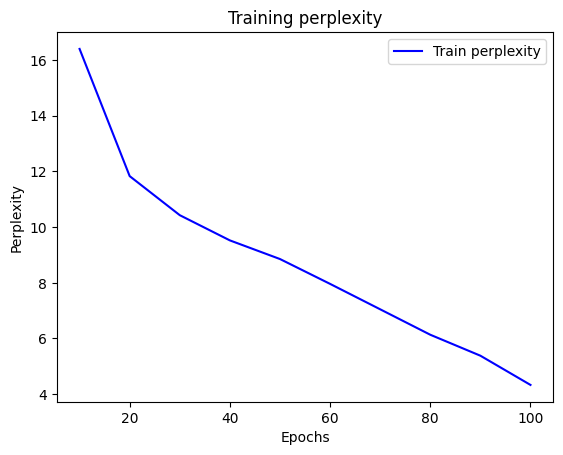

In [250]:
plot_perplexity(perplexities)

# Ex 5

In [251]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import os
import requests
import zipfile
import collections

In [252]:
n_train = 200  # No. of training examples
x_train, _ = torch.sort(torch.rand(n_train) * 5)  # Training inputs

In [253]:
def f(x):
    return (-2) * torch.cosh(x) + x * torch.tanh(x)


y_train = f(x_train) + torch.normal(0.0, 0.25, (n_train,))  # Training outputs

x_test = torch.arange(
    0, 10, 0.05
)

y_truth = f(x_test)  # Ground-truth outputs for the testing examples
n_test = len(x_test)  # No. of testing examples

n_test

200

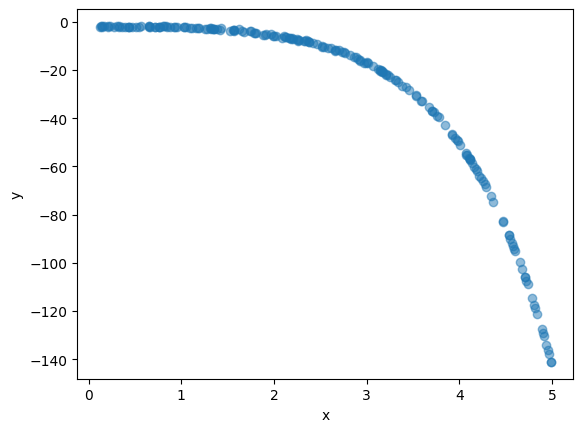

In [254]:
def plot_training_data():
    plt.xlabel("x")
    plt.ylabel("y")
    plt.plot(x_train, y_train, "o", alpha=0.5)


plot_training_data()

In [255]:
def plot_kernel_reg(y_hat):
    plt.plot(x_test, y_truth, label="Truth")
    plt.plot(x_test, y_hat, label="Pred")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim([0, 3])
    plt.ylim(
        [-15, 15]
    )
    plt.legend()
    plt.plot(x_train, y_train, "o", alpha=0.5)

In [256]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        # Shape of the output `queries` and `attention_weights` is:
        # (no. of queries, no. of key-value pairs)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = F.softmax(-((queries - keys) * self.w)**2 / 2, dim=1)
        # Shape of `values` is: (no. of queries, no. of key-value pairs)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)

In [257]:
# Shape of `X_tile` is: (`n_train`, `n_train`), where each column contains the
# same training inputs
X_tile = x_train.repeat((n_train, 1))
# Shape of `Y_tile` is: (`n_train`, `n_train`), where each column contains the
# same training outputs
Y_tile = y_train.repeat((n_train, 1))
# Shape of `keys` is: ('n_train', 'n_train' - 1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# Shape of `values` is: ('n_train', 'n_train' - 1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

In [258]:
def plot_loss_regression(train_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, 'b', label='Train loss')
    plt.title('Training loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

epoch 1, loss 154871.921875
epoch 2, loss 127.123497
epoch 3, loss 127.123497
epoch 4, loss 127.123497
epoch 5, loss 127.123497
epoch 6, loss 127.123497
epoch 7, loss 127.123497
epoch 8, loss 127.123497
epoch 9, loss 127.123497
epoch 10, loss 127.123497
epoch 11, loss 127.123497
epoch 12, loss 127.123497
epoch 13, loss 127.123497
epoch 14, loss 127.123497
epoch 15, loss 127.123497
epoch 16, loss 127.123497
epoch 17, loss 127.123497
epoch 18, loss 127.123497
epoch 19, loss 127.123497
epoch 20, loss 127.123497
Parameter containing:
tensor([165251.4531], requires_grad=True)


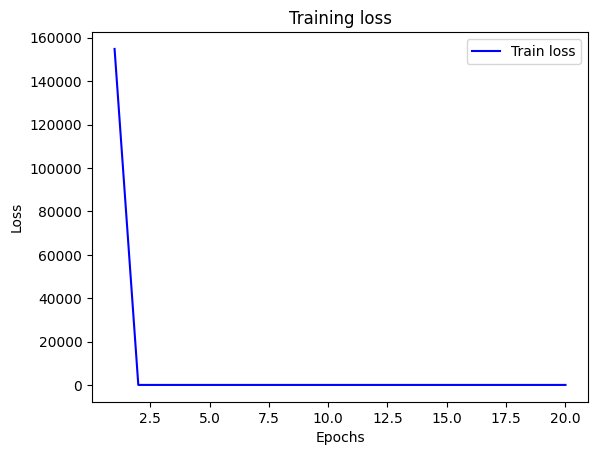

In [259]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
optimizer = torch.optim.SGD(net.parameters(), lr=0.5)
num_epochs = 20
train_loss_all = []
for epoch in range(num_epochs):
    optimizer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    optimizer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    train_loss_all.append(float(l.sum()))

print(net.w)
plot_loss_regression(train_loss_all)

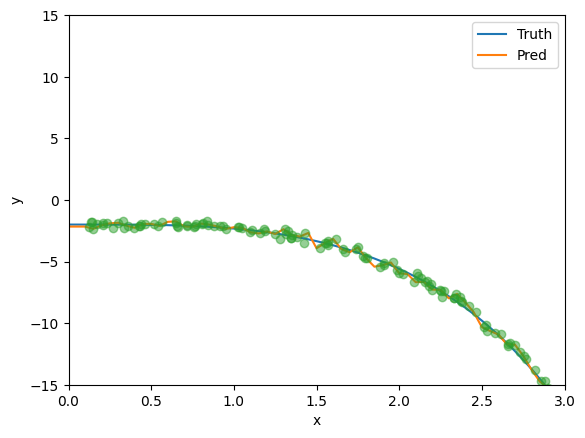

In [260]:
# Shape of `keys` is: (`n_test`, `n_train`), where each column contains the same
# training inputs (i.e., same keys)
keys = x_train.repeat((n_test, 1))
# Shape of `value` is: (`n_test`, `n_train`)
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)

In [261]:
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(5, 5),
                  cmap='Reds'):
    """Show heatmaps of matrices."""
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize,
                             sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6);

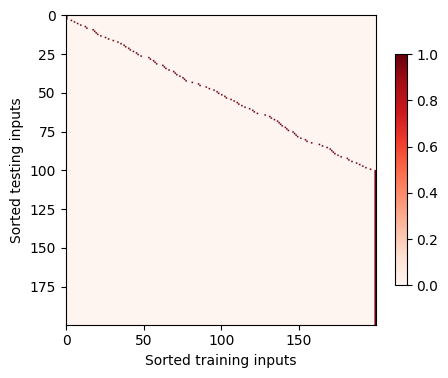

In [262]:
show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
              xlabel='Sorted training inputs',
              ylabel='Sorted testing inputs')